 # Exploratory Data Analysis (EDA)

In [1]:
# Import the required libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load the dataset

In [4]:
df = pd.read_csv("diabetes.csv")

In [5]:
# Display the first five rows of the dataset
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [6]:
# Display information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [7]:
# Check for missing values
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

### Observation

- No missing values were found in the dataset.
- Therefore, no missing value treatment was required.

In [8]:
# Check for duplicate rows
df.duplicated().sum()

np.int64(0)

### Observation

- No duplicate records were found in the dataset.
- Therefore, duplicate removal was not required.

In [9]:
# Display the statistical summary of the dataset
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


# EDA Visualizations

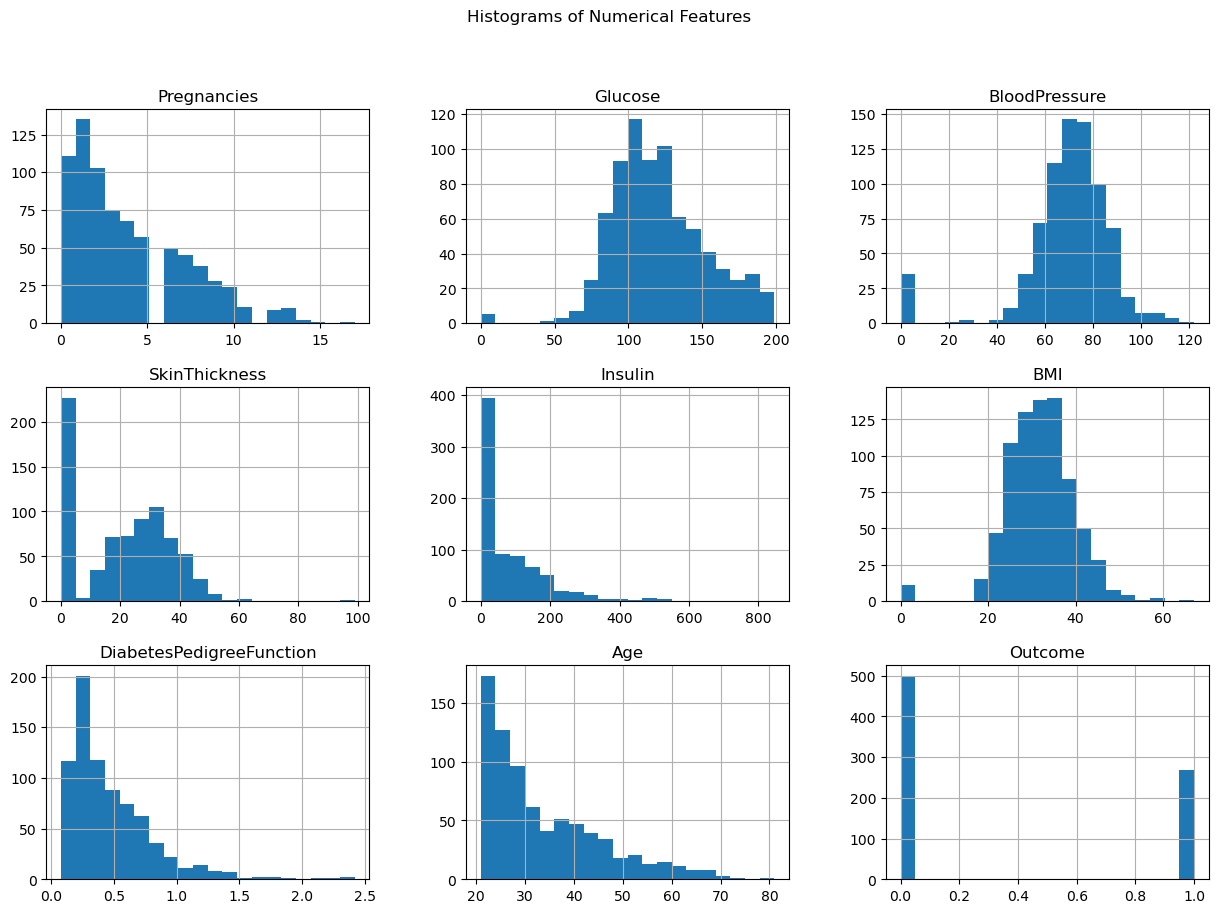

In [10]:
# Create histograms for all numerical features
df.hist(figsize=(15,10), bins=20)
plt.suptitle("Histograms of Numerical Features")
plt.show()

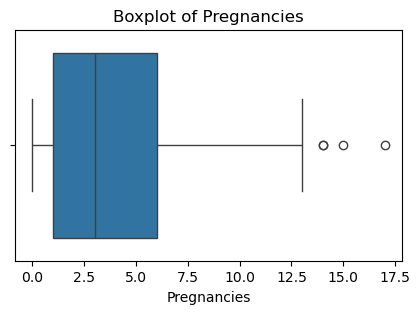

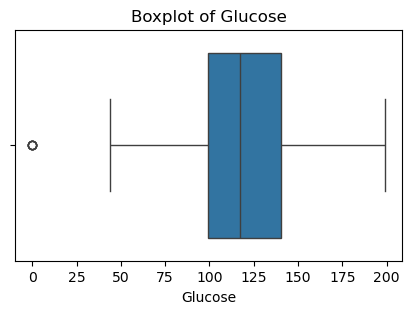

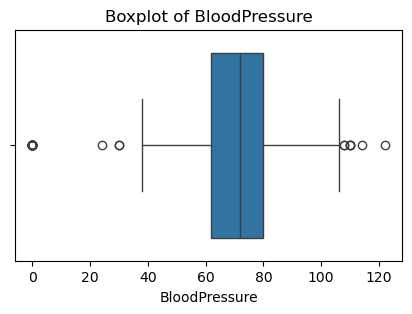

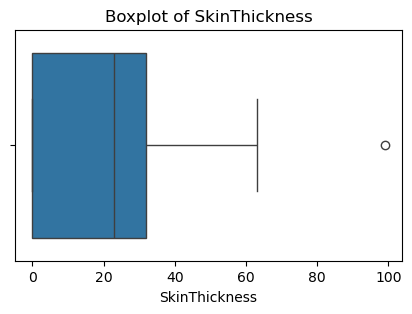

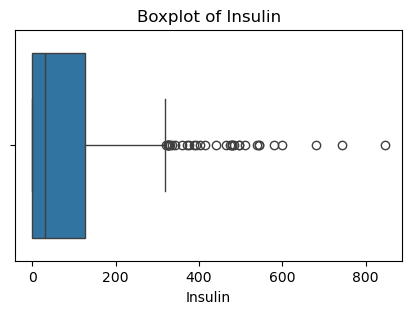

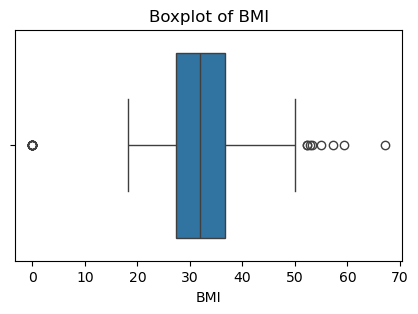

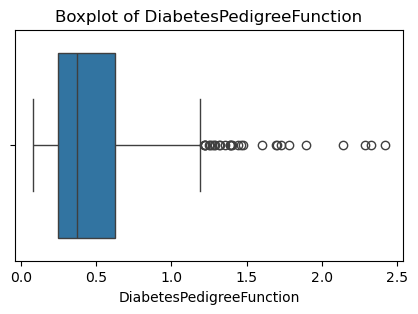

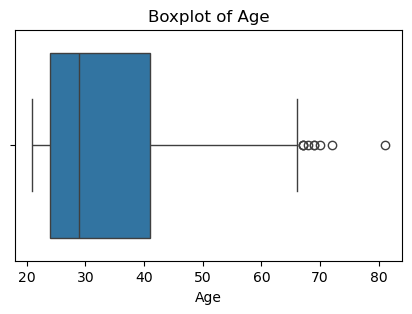

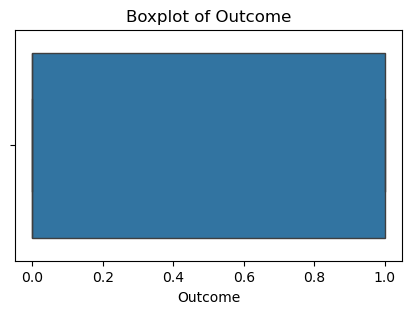

In [11]:
# Create boxplots to detect outliers
for col in df.columns:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

### Observation

- Boxplots indicate the presence of some outliers in features such as Insulin, BMI, and Glucose.
- These observations were retained because they represent valid medical measurements rather than data entry errors.
- Since the assignment focuses on Logistic Regression and the outliers are clinically meaningful, no outlier treatment was performed.

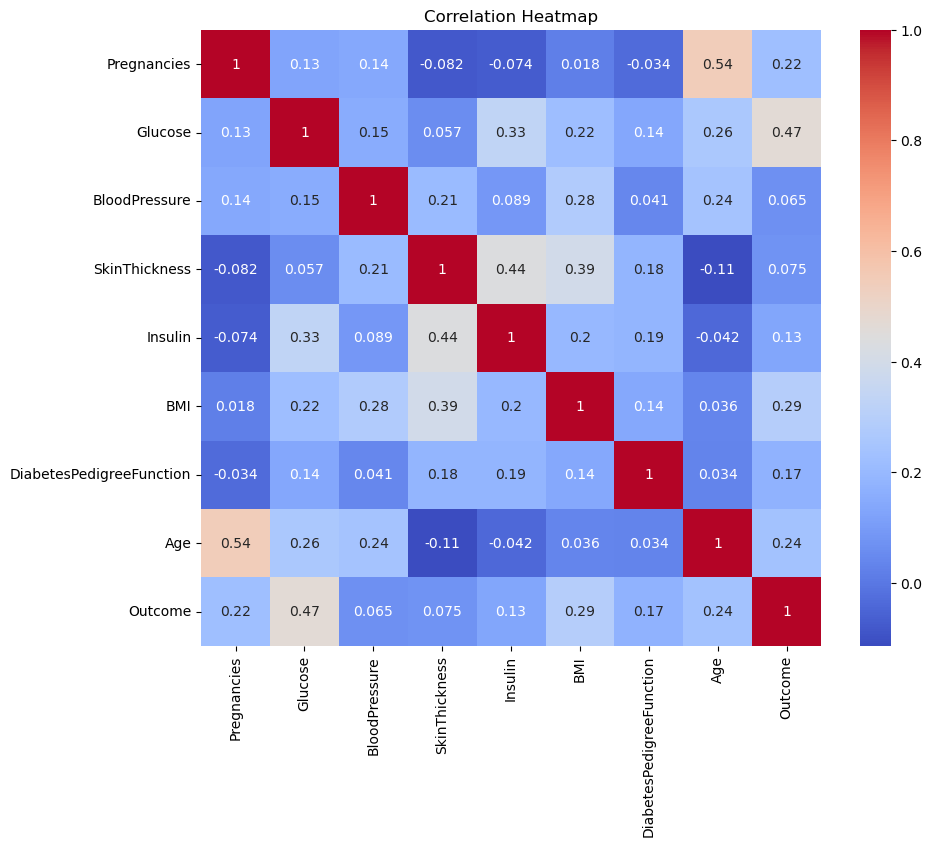

In [12]:
# Create a correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

### Observation

- The correlation heatmap shows the relationships between all numerical features.
- **Glucose** has the strongest positive correlation with the target variable (**Outcome**) (≈ 0.47), indicating it is one of the most important predictors of diabetes.
- **BMI** (≈ 0.29), **Age** (≈ 0.24), and **Pregnancies** (≈ 0.22) also show moderate positive correlations with the target variable.
- Most feature pairs have weak to moderate correlations, indicating that severe multicollinearity is not present.
- The highest correlation among the independent variables is between **Pregnancies** and **Age** (≈ 0.54), which is moderate and acceptable.

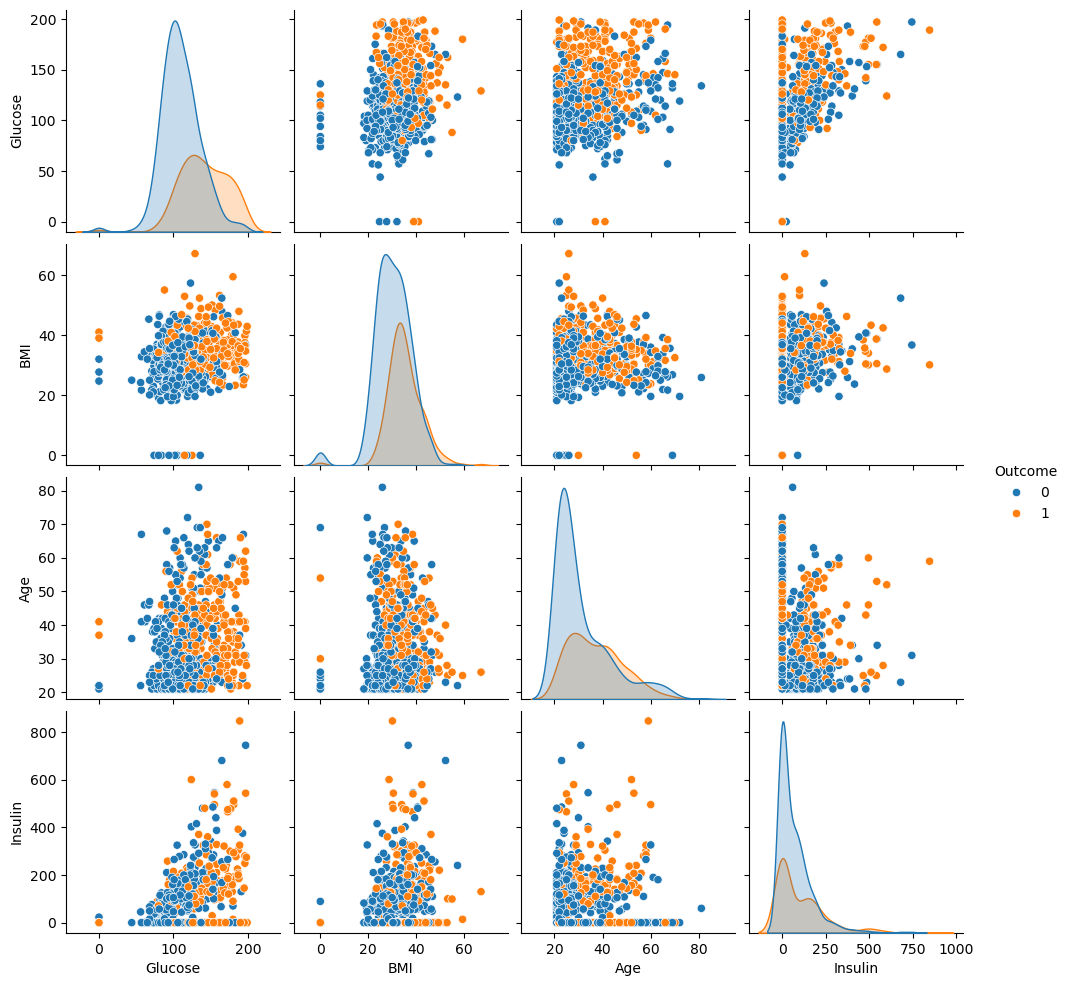

In [13]:
# Create a pair plot for selected important features
sns.pairplot(
    df[['Glucose', 'BMI', 'Age', 'Insulin', 'Outcome']],
    hue='Outcome'
)
plt.show()

## Data Preprocessing

In [14]:
# Count zero values in columns where zero is medically invalid

cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

(df[cols] == 0).sum()

Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

In [15]:
# Replace medically invalid zero values with NaN
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

df[cols] = df[cols].replace(0, np.nan)

In [16]:
# Check the missing values after replacing zeros with NaN
df.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [17]:
# Fill missing values with the median of each column
df[cols] = df[cols].fillna(df[cols].median())

In [18]:
# Verify that all missing values have been handled
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

### Observation

- Although the dataset did not contain explicit missing values, several medical variables contained zero values that are not physiologically valid.
- These zero values were treated as missing values by replacing them with NaN.
- The missing values were then imputed using the median of each feature because the median is less sensitive to outliers than the mean.
- This preprocessing step improves the quality of the data for Logistic Regression.

In [19]:
# Separate the independent variables (X) and target variable (y)
X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [20]:
# Split the dataset into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [21]:
# Standardize the feature values
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [22]:
# Display the shape of the training and testing datasets
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (614, 8)
X_test : (154, 8)
y_train: (614,)
y_test : (154,)


### Model Building

In [23]:
# Import the Logistic Regression model and evaluation metrics
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

In [24]:
# Create a Logistic Regression model
model = LogisticRegression(random_state=42)

In [25]:
# Train the Logistic Regression model
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


### Make Predictions

In [26]:
# Predict the class labels for the test dataset
y_pred = model.predict(X_test)

In [27]:
# Predict the probabilities for the positive class
y_prob = model.predict_proba(X_test)[:,1]

In [28]:
# Calculate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7532467532467533


In [29]:
# Display the confusion matrix
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[82 17]
 [21 34]]


In [30]:
# Display the classification report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.83      0.81        99
           1       0.67      0.62      0.64        55

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.73       154
weighted avg       0.75      0.75      0.75       154



In [31]:
precision = precision_score(y_test, y_pred)

print("Precision:", precision)

Precision: 0.6666666666666666


In [32]:
recall = recall_score(y_test, y_pred)

print("Recall:", recall)

Recall: 0.6181818181818182


In [33]:
f1 = f1_score(y_test, y_pred)

print("F1 Score:", f1)

F1 Score: 0.6415094339622641


In [34]:
roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.82277318640955


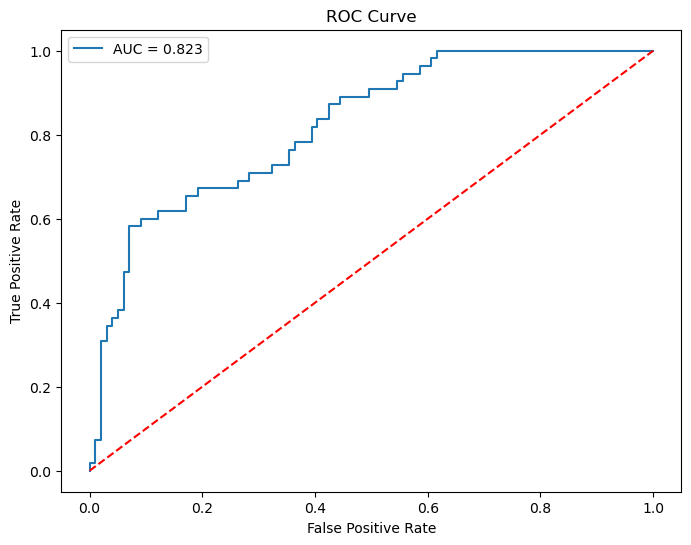

In [35]:
# Plot the ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

### Observation

- The Logistic Regression model achieved an accuracy of **75.32%** on the test dataset.
- The precision score of **66.67%** indicates that approximately two-thirds of the patients predicted as diabetic were correctly classified.
- The recall score of **61.82%** shows that the model correctly identified a majority of diabetic patients.
- The ROC-AUC score of **82.28%** indicates good discriminative ability between diabetic and non-diabetic patients.
- Overall, the model demonstrates good classification performance for diabetes prediction.

In [37]:
# Display the coefficients of the Logistic Regression model
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coefficients.sort_values(by="Coefficient", ascending=False)

,Feature,Coefficient
1,Glucose,1.102682
5,BMI,0.688839
7,Age,0.392410
0,Pregnancies,0.222978
6,DiabetesPedigreeFunction,0.203635
3,SkinThickness,0.068836
4,Insulin,-0.138252
2,BloodPressure,-0.151540


### Observation

- The Logistic Regression coefficients indicate the direction and strength of the relationship between each feature and the probability of diabetes.
- **Glucose** has the highest positive coefficient, making it the most influential predictor of diabetes.
- **BMI** and **Age** also have strong positive effects, indicating that higher values increase the likelihood of diabetes.
- **Pregnancies** and **DiabetesPedigreeFunction** have moderate positive contributions.
- **Insulin** and **BloodPressure** have small negative coefficients after accounting for the influence of the other variables.
- Overall, Glucose, BMI, and Age are the most significant predictors in this Logistic Regression model.

### Interview Question 1

## Difference between Precision and Recall

**Precision** measures the proportion of correctly predicted positive observations out of all observations predicted as positive.

Precision = TP / (TP + FP)

It is important when the cost of false positives is high.

**Recall** measures the proportion of correctly predicted positive observations out of all actual positive observations.

Recall = TP / (TP + FN)

It is important when the cost of false negatives is high, such as in medical diagnosis.

### Interview Question 2

## What is Cross-Validation?

Cross-validation is a model evaluation technique used to assess how well a machine learning model generalizes to unseen data.

The most common method is **K-Fold Cross-Validation**, where the dataset is divided into K equal folds. The model is trained K times, each time using one fold for testing and the remaining folds for training. The final performance is calculated as the average of all K iterations.

Cross-validation helps reduce overfitting and provides a more reliable estimate of model performance.

## Conclusion

In this assignment, Logistic Regression was used to predict whether a patient has diabetes based on various medical features. Exploratory Data Analysis (EDA) and data preprocessing were performed, including handling hidden missing values and feature standardization. The Logistic Regression model was trained and evaluated using several classification metrics.

The model achieved an accuracy of **75.32%** and a ROC-AUC score of **82.28%**, indicating good predictive performance. Overall, the model demonstrates that Logistic Regression is an effective algorithm for binary classification problems such as diabetes prediction.

## Final Summary

- Performed Exploratory Data Analysis (EDA).
- Treated hidden missing values using median imputation.
- Standardized the features using StandardScaler.
- Built and evaluated a Logistic Regression model.
- Achieved an accuracy of **75.32%** and a ROC-AUC score of **82.28%**.
- Glucose, BMI, and Age were identified as the most important predictors of diabetes.